# NLP de Conversaciones Havi — Hey Banco Datathon 2026

**Objetivo:** descubrir tópicos en las conversaciones de los clientes con Havi y cruzarlos con los clusters comportamentales para encontrar **necesidades implícitas**.

**Pipeline:**
1. Carga del dataset Havi (CSV) y validación del overlap con clientes
2. Concatenación a nivel conversación (solo inputs del usuario, sin marcadores)
3. Embeddings con `sentence-transformers` multilingual
4. BERTopic: UMAP + HDBSCAN + c-TF-IDF para identificar tópicos interpretables
5. Agregación de tópicos a nivel usuario (vector de proporciones)
6. Cruce con clusters comportamentales — **la pieza que vende el reto**
7. Visualizaciones para el pitch
8. Export final

**Hallazgos clave del dataset:**
- Overlap perfecto: los 15,025 usuarios Havi son los mismos 15,025 clientes Hey
- ~24,119 conversaciones únicas, mediana de 2 turnos por conversación
- 94% texto, 6% voz
- Mensajes cortos: mediana 36 chars (chat-like, no emails largos)
- Idioma: español

In [1]:
import nbformat
import IPython

print(nbformat.__version__)

5.10.4


---
## 1. Setup

Si falta alguna librería:
```
!pip install sentence-transformers bertopic umap-learn hdbscan plotly --quiet
```

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_DIR = '../data'
RANDOM_STATE = 42

print('Setup listo.')

Setup listo.


---
## 2. Carga y exploración rápida

In [3]:
df_havi = pd.read_csv(f'{DATA_DIR}/dataset_50k_anonymized.csv')

# Cargar también clusters (para el cruce posterior)
master = pd.read_csv(f'{DATA_DIR}/master_with_clusters.csv')

print(f'Havi:    {df_havi.shape}')
print(f'Master:  {master.shape}')

# Validar overlap
overlap = set(df_havi['user_id']) & set(master['user_id'])
print(f'\nOverlap user_id Havi ∩ Master: {len(overlap):,} usuarios')

Havi:    (49999, 6)
Master:  (15025, 140)

Overlap user_id Havi ∩ Master: 15,025 usuarios


In [4]:
# Limpieza básica
df_havi['input'] = df_havi['input'].fillna('')  # 23 nulls
df_havi['date'] = pd.to_datetime(df_havi['date'], errors='coerce')

# Cuántas conversaciones tiene cada usuario
print('Conversaciones por usuario:')
print(df_havi.groupby('user_id')['conv_id'].nunique().describe())

# Channel source: 1=texto, 2=voz
print(f'\nDistribución por canal:')
print(df_havi['channel_source'].value_counts())

Conversaciones por usuario:
count   15,025.000
mean         1.605
std          1.060
min          1.000
25%          1.000
50%          1.000
75%          2.000
max         24.000
Name: conv_id, dtype: float64

Distribución por canal:
channel_source
1    46936
2     3063
Name: count, dtype: int64


---
## 3. Construcción de la tabla de conversaciones

**Decisión clave:** concatenamos solo los `input` del usuario, ordenados cronológicamente, sin marcadores tipo "Usuario:". 

**Por qué solo inputs:** las respuestas de Havi son repetitivas (saludos similares, formato común) y dominarían los embeddings, llevando a clusters de "tipos de respuesta del bot" en lugar de "tipos de necesidad del cliente".

In [5]:
# Ordenar por fecha dentro de cada conversación
df_havi = df_havi.sort_values(['conv_id', 'date']).reset_index(drop=True)

# Agrupar por conversación, concatenando solo inputs
conversaciones = (
    df_havi.groupby(['user_id', 'conv_id'], as_index=False)
           .agg(
               conversacion=('input', lambda x: ' '.join(x.fillna('').astype(str)).strip()),
               n_turnos=('input', 'count'),
               canal=('channel_source', 'first'),
               fecha_inicio=('date', 'min'),
               fecha_fin=('date', 'max'),
           )
)

# Filtrar conversaciones con texto trivial
antes = len(conversaciones)
conversaciones = conversaciones[conversaciones['conversacion'].str.len() > 5].reset_index(drop=True)
print(f'Conversaciones antes/después de filtro: {antes:,} → {len(conversaciones):,}')
print(f'Largo medio (chars): {conversaciones["conversacion"].str.len().mean():.0f}')
print(f'Largo p95 (chars):   {conversaciones["conversacion"].str.len().quantile(0.95):.0f}')

conversaciones.head(3)

Conversaciones antes/después de filtro: 24,119 → 24,032
Largo medio (chars): 90
Largo p95 (chars):   255


,user_id,conv_id,conversacion,n_turnos,canal,fecha_inicio,fecha_fin
0,USR-00001,B9B6507D-9D83-479A-A357-A01343D83599,Mi tarjeta de crédito tiene comisión? Mi tarje...,3,1,2025-08-07,2025-08-07
1,USR-00002,C8EE8171-1142-4DCD-9EFA-1EE2D58E708C,Hola buenos días Ya liquide mi crédito de auto...,3,1,2025-09-17,2025-09-17
2,USR-00003,cc0fa1a8c8d14c2095e7c7417be14043,Requiero asistencia para poder ingresar a mi b...,3,1,2025-10-11,2025-10-11


---
## 4. Embeddings

**Modelo:** `paraphrase-multilingual-MiniLM-L12-v2`
- Multilingual (maneja español sin problema)
- Pequeño (~120 MB), corre en CPU en minutos
- Vectores de 384 dimensiones

**Tiempo estimado:** ~5-10 min en CPU para 24k conversaciones cortas. En GPU: <1 min.

In [6]:
import time

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print('Calculando embeddings...')
t0 = time.time()
embeddings = model.encode(
    conversaciones['conversacion'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f'Listo: {time.time()-t0:.1f}s. Shape: {embeddings.shape}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6947.04it/s]


Calculando embeddings...


Batches: 100%|██████████| 376/376 [00:30<00:00, 12.48it/s]

Listo: 30.2s. Shape: (24032, 384)


In [7]:
# CRÍTICO: guardar a disco. Re-calcular embeddings es lo más caro del pipeline.
# Si iteran hiperparámetros de BERTopic, lo recargan en lugar de re-calcular.
np.save(f'{DATA_DIR}/havi_embeddings.npy', embeddings)
print(f'Embeddings guardados en {DATA_DIR}/havi_embeddings.npy')
# Para recargar: embeddings = np.load(f'{DATA_DIR}/havi_embeddings.npy')

Embeddings guardados en ../data/havi_embeddings.npy


---
## 5. BERTopic — Detección de tópicos

BERTopic combina:
- **UMAP** (reducción 384D → 5D)
- **HDBSCAN** (clustering basado en densidad)
- **c-TF-IDF** (extrae las palabras clave que definen cada tópico)

**Resultado:** ~15-25 tópicos interpretables como "consulta de saldo", "problema con tarjeta", "interés en inversión", etc.

**Hiperparámetros pensados para este dataset:**
- `min_topic_size=80` con 24k convs → ~15-25 tópicos (sweet spot para pitch)
- `n_neighbors=15` en UMAP → balance estructura local/global

In [8]:
# Stopwords en español (BERTopic por default usa inglés — tópicos saldrían como 'el_de_la_que')
STOPWORDS_ES = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por',
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero',
    'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando',
    'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien',
    'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra',
    'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos',
    'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos',
    'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas',
    'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus',
    'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos',
    'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas',
    'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 'vuestra',
    'vuestros', 'vuestras', 'esos', 'esas', 'es', 'son', 'fue', 'ser', 'soy',
    'eres', 'somos', 'sois', 'fui', 'fuiste', 'fuimos', 'fuisteis', 'fueron',
    'estoy', 'estás', 'está', 'estamos', 'estáis', 'están', 'estaba', 'estaban',
    'he', 'has', 'ha', 'hemos', 'habéis', 'han', 'había', 'habían', 'hola',
    'gracias', 'buenos', 'buenas', 'dias', 'días', 'tardes', 'noches',
    'puedo', 'puede', 'pueden', 'podría', 'podrías', 'cómo', 'qué', 'cuál',
    'quiero', 'quieres', 'quiere', 'necesito', 'ayuda', 'favor', 'porfa',
    'si', 'asi', 'así', 'ahora', 'bien', 'mal', 'solo', 'sólo', 'aún', 'aun',
    'va', 'voy', 'haber', 'hacer', 'hace', 'hacen', 'hago',
]

# Configuración explícita de cada componente (más control que defaults)
umap_model = UMAP(
    n_neighbors=15, n_components=5, min_dist=0.0,
    metric='cosine', random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=80, min_samples=15,
    metric='euclidean', cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS_ES,
    ngram_range=(1, 2),  # uni y bigramas: 'tarjeta bloqueada' como unidad
    min_df=20            # palabra/bigrama debe aparecer en ≥20 convs
)

topic_model = BERTopic(
    embedding_model=None,           # ya tenemos embeddings
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language='multilingual',
    calculate_probabilities=False,
    verbose=True
)

print('Ajustando BERTopic...')
t0 = time.time()
docs = conversaciones['conversacion'].tolist()
topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
print(f'Listo: {time.time()-t0:.1f}s')

conversaciones['topic_id'] = topics

n_topics = len(set(topics)) - (1 if -1 in topics else 0)
n_outlier = sum(1 for t in topics if t == -1)
print(f'\nTópicos identificados: {n_topics}')
print(f'Conversaciones outlier (-1): {n_outlier:,} ({100*n_outlier/len(topics):.1f}%)')

2026-04-25 18:19:08,584 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Ajustando BERTopic...


2026-04-25 18:19:28,785 - BERTopic - Dimensionality - Completed ✓
2026-04-25 18:19:28,786 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-25 18:19:30,757 - BERTopic - Cluster - Completed ✓
2026-04-25 18:19:30,762 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-25 18:19:30,973 - BERTopic - Representation - Completed ✓


Listo: 22.5s

Tópicos identificados: 68
Conversaciones outlier (-1): 6,812 (28.3%)


### 5.1 Inspección de tópicos

Aquí es donde **el equipo** asigna nombres interpretables. BERTopic da palabras clave; tú decides el nombre legible.

In [9]:
# Tabla resumen
topic_info = topic_model.get_topic_info()
print(f'Tabla de tópicos: {topic_info.shape}')
topic_info.head(20)

Tabla de tópicos: (69, 5)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,6812,-1_tarjeta crédito_cuenta_crédito_tarjeta,"[tarjeta crédito, cuenta, crédito, tarjeta, pa...",[Hola Cómo puedo ser hey pro? Quiero saber cóm...
1,0,1472,0_tarjeta física_física_tarjeta_nueva,"[tarjeta física, física, tarjeta, nueva, costo...","[Está por vencer mi tarjeta física, me mandará..."
2,1,1126,1_atención_cliente_clientes_número,"[atención, cliente, clientes, número, atención...","[Cuál es el número de atención a clientes?, Nú..."
3,2,860,2_banco_hey banco_banregio_clabe,"[banco, hey banco, banregio, clabe, hey, depos...",[Para que me hagan una transferencia con mi nu...
4,3,734,3_aclaración_estado_estado cuenta_cajeros,"[aclaración, estado, estado cuenta, cajeros, a...","[Donde puedo ver el estado de una aclaración?,..."
5,4,685,4_compra_reflejado_dinero_pago,"[compra, reflejado, dinero, pago, pendiente, c...",[No se ha reflejado el dinero de una compra qu...
6,5,581,5_meses_mil_año_10,"[meses, mil, año, 10, crédito, pesos, 24, mont...",[Cómo es el crédito asunto? Cómo es el crédito...
7,6,415,6_verificar_activar_tarjeta_poner,"[verificar, activar, tarjeta, poner, pide, usa...",[cómo puedo verificar mi tarjeta para apple pa...
8,7,398,7_cancelar_tarjeta crédito_garantía_garantizada,"[cancelar, tarjeta crédito, garantía, garantiz...","[Quiero cancelar tarjeta de crédito, Como canc..."
9,8,389,8_cargo_cargo reconocido_reconocido_reportar,"[cargo, cargo reconocido, reconocido, reportar...","[Cómo puedo reportar un cargo no reconocido, n..."


In [10]:
# Inspección detallada: palabras clave + ejemplos representativos por tópico
for tid in sorted([t for t in set(topics) if t != -1])[:15]:  # primeros 15 tópicos
    print(f'\n{"="*70}')
    print(f'TÓPICO {tid}')
    print(f'{"="*70}')
    
    # Palabras clave (top 10)
    palabras = topic_model.get_topic(tid)[:10]
    print(f'Palabras clave: {", ".join([w for w, _ in palabras])}')
    
    # Conversaciones representativas
    rep = topic_model.get_representative_docs(tid)[:2]
    print(f'\nEjemplos representativos:')
    for i, doc in enumerate(rep, 1):
        print(f'  [{i}] {doc[:200]}{"..." if len(doc) > 200 else ""}')
    
    n = sum(1 for t in topics if t == tid)
    print(f'\nTamaño: {n:,} conversaciones ({100*n/len(topics):.1f}%)')


TÓPICO 0
Palabras clave: tarjeta física, física, tarjeta, nueva, costo, fisica, solicitar, pedir, tiene, solicito

Ejemplos representativos:
  [1] Está por vencer mi tarjeta física, me mandarán una nueva?
  [2] Hola  Cómo puedo hacer para elegir el diseño de nueva tarjeta física?  ¿  Qué  diseños hay  para  elegir ?

Tamaño: 1,472 conversaciones (6.1%)

TÓPICO 1
Palabras clave: atención, cliente, clientes, número, atención clientes, número atención, teléfono, servicio, hablar, agente

Ejemplos representativos:
  [1] Cuál es el número de atención a clientes?
  [2] Número atención a clientes

Tamaño: 1,126 conversaciones (4.7%)

TÓPICO 2
Palabras clave: banco, hey banco, banregio, clabe, hey, depositar, cuenta clabe, clave, cambio, cuenta

Ejemplos representativos:
  [1] Para que me hagan una transferencia con mi nueva cuenta clabe se busca como hey banco o banregio?
  [2] bajo que banco está mi cuenta? 

Banregio o Hey Banco?

Tamaño: 860 conversaciones (3.6%)

TÓPICO 3
Palabras clave:

### 5.2 Etiquetado humano de tópicos

Después de inspeccionar, mapear `topic_id` → nombre de negocio. Ejemplos típicos en banca:

In [11]:
# 👇 RELLENAR DESPUÉS DE INSPECCIONAR LOS TÓPICOS 👇
etiquetas_topicos = {
    -1: 'sin_topico',
    # 0: 'consulta_saldo',
    # 1: 'tarjeta_credito_problema',
    # 2: 'interes_inversion',
    # 3: 'queja_cargo_no_reconocido',
    # 4: 'duda_cashback',
    # 5: 'remesas_consulta',
    # ...
}

# Default para los no etiquetados
for tid in set(topics):
    if tid not in etiquetas_topicos:
        # Usar las 3 primeras palabras clave como nombre tentativo
        if tid != -1:
            words = topic_model.get_topic(tid)[:3]
            etiquetas_topicos[tid] = '_'.join([w for w, _ in words])
        else:
            etiquetas_topicos[tid] = 'sin_topico'

conversaciones['topic_label'] = conversaciones['topic_id'].map(etiquetas_topicos)
print('Etiquetas asignadas. Top 10 tópicos por volumen:')
print(conversaciones['topic_label'].value_counts().head(10).to_string())

Etiquetas asignadas. Top 10 tópicos por volumen:
topic_label
sin_topico                           6812
tarjeta física_física_tarjeta        1472
atención_cliente_clientes            1126
banco_hey banco_banregio              860
aclaración_estado_estado cuenta       734
compra_reflejado_dinero               685
meses_mil_año                         581
verificar_activar_tarjeta             557
cancelar_tarjeta crédito_garantía     398
cargo_cargo reconocido_reconocido     389


---
## 6. Agregación de tópicos a nivel usuario

Hasta ahora cada **conversación** tiene un tópico. Para cruzar con clusters comportamentales necesitamos un vector por **usuario**.

**Lógica:** para cada usuario, qué proporción de sus conversaciones cae en cada tópico. Resultado: matriz `(n_usuarios × n_tópicos)`.

In [12]:
# Pivot: filas=usuario, cols=tópico, valores=# convs
user_topic_counts = (
    conversaciones
    .groupby(['user_id', 'topic_id'])
    .size()
    .unstack(fill_value=0)
)

# Normalizar a proporciones por usuario
user_topic_pct = user_topic_counts.div(user_topic_counts.sum(axis=1), axis=0).fillna(0)

# Renombrar con prefijo havi_topic_
user_topic_pct.columns = [f'havi_topic_{c}' for c in user_topic_pct.columns]

# Features adicionales sobre comportamiento conversacional
user_havi_meta = (
    df_havi.groupby('user_id').agg(
        havi_n_convs=('conv_id', 'nunique'),
        havi_n_turnos_total=('input', 'count'),
        havi_pct_voz=('channel_source', lambda x: (x == 2).mean()),
    )
)
user_havi_meta['havi_turnos_x_conv'] = (
    user_havi_meta['havi_n_turnos_total'] / user_havi_meta['havi_n_convs']
)

# Combinar
user_havi_features = user_havi_meta.join(user_topic_pct, how='left').fillna(0)

print(f'Features Havi por usuario: {user_havi_features.shape}')
print(f'\nFlag: tuvo conversación con Havi (todos en este dataset):')
user_havi_features.head(3)

Features Havi por usuario: (15025, 73)

Flag: tuvo conversación con Havi (todos en este dataset):


,havi_n_convs,havi_n_turnos_total,havi_pct_voz,havi_turnos_x_conv,havi_topic_-1,havi_topic_0,havi_topic_1,havi_topic_2,havi_topic_3,havi_topic_4,havi_topic_5,havi_topic_6,havi_topic_7,havi_topic_8,havi_topic_9,havi_topic_10,havi_topic_11,havi_topic_12,havi_topic_13,havi_topic_14,havi_topic_15,havi_topic_16,havi_topic_17,havi_topic_18,havi_topic_19,...,havi_topic_43,havi_topic_44,havi_topic_45,havi_topic_46,havi_topic_47,havi_topic_48,havi_topic_49,havi_topic_50,havi_topic_51,havi_topic_52,havi_topic_53,havi_topic_54,havi_topic_55,havi_topic_56,havi_topic_57,havi_topic_58,havi_topic_59,havi_topic_60,havi_topic_61,havi_topic_62,havi_topic_63,havi_topic_64,havi_topic_65,havi_topic_66,havi_topic_67
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
USR-00001,1,3,0.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
USR-00002,1,3,0.000,3.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
USR-00003,1,3,0.000,3.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


---
## 7. EL CRUCE: tópicos × clusters

**Esta es la pieza que vende el reto.** Por primera vez podemos responder: *¿qué temas verbalizan los clientes de cada segmento?*

Un cluster "Premium Digital" que habla mayoritariamente de "interés en inversión" → trigger claro de cross-sell.

Un cluster "Joven Aspiracional" que habla mayoritariamente de "problemas con tarjeta" → trigger de fricción que puede generar churn.

In [16]:
cluster_topic_matrix = cluster_topic_matrix.loc[:, ~cluster_topic_matrix.columns.duplicated()]

In [17]:
# Pegar features Havi al master
master_havi = master.merge(user_havi_features, on='user_id', how='left')
# Usuarios sin Havi → 0 (no aplica en este dataset porque overlap es 100%)
havi_cols = user_havi_features.columns.tolist()
master_havi[havi_cols] = master_havi[havi_cols].fillna(0)

print(f'Master enriquecido: {master_havi.shape}')

# Cruce tópico × cluster — la matriz que mostraremos en el pitch
topic_cols = [c for c in master_havi.columns if c.startswith('havi_topic_')]
topic_cols_no_outlier = [c for c in topic_cols if not c.endswith('_-1')]

cluster_topic_matrix = (
    master_havi[master_havi['cluster_id'] != -1]
    .groupby('cluster_id')[topic_cols_no_outlier]
    .mean()
)

# Renombrar columnas usando las etiquetas humanas
rename_map = {}
for c in cluster_topic_matrix.columns:
    tid = int(c.replace('havi_topic_', ''))
    rename_map[c] = etiquetas_topicos.get(tid, c)
cluster_topic_matrix = cluster_topic_matrix.rename(columns=rename_map)

print(f'\nMatriz cluster × tópico: {cluster_topic_matrix.shape}')
cluster_topic_matrix.round(3).head()

Master enriquecido: (15025, 213)

Matriz cluster × tópico: (17, 68)


,tarjeta física_física_tarjeta,atención_cliente_clientes,banco_hey banco_banregio,aclaración_estado_estado cuenta,compra_reflejado_dinero,meses_mil_año,verificar_activar_tarjeta,cancelar_tarjeta crédito_garantía,cargo_cargo reconocido_reconocido,app_aplicación_celular,meses_préstamo_personal,personal_credito_crédito,transferir_banco_débito,límite_mes_depósito,línea_linea_límite,token_correcto_encuentro,beneficios_ir_tarjeta hey,hey_dinero_hoy,movimiento_movimientos_estado cuenta,nip_tarjeta_compra,hablar asesor_asesor_hablar,anualidad_efectivo_tarjeta crédito,retirar_comisión_cajeros,cancelar_cuenta_cuenta hey,tarjeta crédito_garantizada_crédito,...,anualidad_beneficios_promoción,transferencia_hice_llegado,abrir_cuenta_cuenta hey,cancelar_tdc_nómina,requisitos_crédito_solicitar,cuenta hey_hey banco_cuentas,estados_recibir_dinero,pago_pagos_pagar,transferencia_hice_transferencias,depositar_depósito_deposito,app_pagar_pago,token_correcto_dice,préstamo_personal_solicitar,clave_ver_dónde,cargo reconocido_reconocido_cargo,pagar_pago_app,cargos_pendiente_cargo,cuenta_tengo saldo_saldo,transferencia_cancelar_transferencias,encuentro_código_activo,liquidar_pagar_crédito,digital_tarjeta_quitar,nip_clabe_cambio,hablar_dame_contactar,código_beneficios_promoción
cluster_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.082,0.051,0.032,0.025,0.031,0.042,0.023,0.008,0.013,0.018,0.025,0.009,0.016,0.007,0.009,0.020,0.012,0.021,0.006,0.007,0.011,0.012,0.004,0.008,0.014,...,0.004,0.010,0.012,0.000,0.007,0.003,0.007,0.004,0.004,0.006,0.002,0.006,0.003,0.002,0.000,0.005,0.003,0.004,0.001,0.002,0.007,0.004,0.003,0.002,0.001
1,0.044,0.044,0.026,0.028,0.016,0.021,0.018,0.024,0.022,0.019,0.024,0.017,0.022,0.006,0.014,0.020,0.011,0.009,0.010,0.013,0.008,0.011,0.011,0.012,0.007,...,0.010,0.003,0.005,0.011,0.002,0.012,0.004,0.002,0.005,0.008,0.008,0.005,0.007,0.006,0.010,0.003,0.007,0.007,0.001,0.007,0.005,0.002,0.000,0.002,0.000
2,0.062,0.044,0.027,0.030,0.028,0.042,0.015,0.012,0.015,0.019,0.014,0.012,0.013,0.015,0.013,0.014,0.015,0.011,0.009,0.012,0.012,0.013,0.012,0.009,0.008,...,0.007,0.004,0.008,0.006,0.003,0.005,0.003,0.004,0.005,0.001,0.007,0.005,0.004,0.003,0.003,0.004,0.004,0.003,0.006,0.005,0.005,0.005,0.002,0.003,0.004
3,0.063,0.039,0.053,0.030,0.021,0.025,0.013,0.026,0.022,0.013,0.013,0.015,0.013,0.011,0.022,0.011,0.017,0.017,0.007,0.019,0.006,0.007,0.005,0.004,0.009,...,0.003,0.002,0.004,0.007,0.008,0.004,0.006,0.001,0.004,0.011,0.003,0.001,0.007,0.004,0.001,0.003,0.002,0.004,0.001,0.002,0.000,0.004,0.003,0.002,0.001
4,0.059,0.042,0.038,0.024,0.030,0.028,0.020,0.016,0.014,0.019,0.016,0.017,0.015,0.012,0.011,0.011,0.013,0.012,0.008,0.009,0.007,0.011,0.009,0.013,0.011,...,0.006,0.006,0.006,0.003,0.008,0.007,0.006,0.005,0.007,0.005,0.005,0.006,0.006,0.004,0.003,0.004,0.004,0.004,0.003,0.003,0.005,0.004,0.005,0.003,0.005


In [19]:
cluster_topic_matrix = cluster_topic_matrix.loc[:, ~cluster_topic_matrix.columns.duplicated()]

In [22]:
cid = cluster_topic_matrix.index[0]
topic = cluster_topic_matrix.columns[0]

print(type(cluster_topic_matrix.loc[cid, topic]))

<class 'numpy.float64'>


In [23]:
print(cluster_topic_matrix.columns.duplicated().sum())

0


In [24]:
print(type(cluster_topic_matrix.loc[cid, topic]))

<class 'numpy.float64'>


In [25]:
cluster_topic_matrix.columns.duplicated().sum()

np.int64(0)

In [26]:
cluster_topic_matrix = cluster_topic_matrix.loc[:, ~cluster_topic_matrix.columns.duplicated()]

In [27]:
# Para cada cluster, los 3 tópicos más distintivos
# (usar Z-score entre clusters para destacar lo que es único de cada uno)
from scipy.stats import zscore

z_matrix = cluster_topic_matrix.apply(zscore).fillna(0)

print('Top 3 tópicos distintivos por cluster:')
for cid in z_matrix.index:
    top3 = z_matrix.loc[cid].sort_values(ascending=False).head(3)
    n = (master_havi['cluster_id'] == cid).sum()
    print(f'\n📍 Cluster {cid} (n={n:,}):')
    for topic, z in top3.items():
        pct = cluster_topic_matrix.loc[cid, topic] * 100
        print(f'   • {topic:40s} {pct:>5.1f}% de sus convs (z={z:+.2f})')

Top 3 tópicos distintivos por cluster:

📍 Cluster 0 (n=525):
   • tarjeta física_física_tarjeta              8.2% de sus convs (z=+2.50)
   • hey_dinero_hoy                             2.1% de sus convs (z=+2.15)
   • transferencia_hice_llegado                 1.0% de sus convs (z=+2.14)

📍 Cluster 1 (n=294):
   • app_aplicación_nueva                       2.2% de sus convs (z=+3.07)
   • cargo reconocido_reconocido_cargo          1.0% de sus convs (z=+2.90)
   • cuenta hey_hey banco_cuentas               1.2% de sus convs (z=+2.59)

📍 Cluster 2 (n=1,939):
   • transferencia_cancelar_transferencias      0.6% de sus convs (z=+1.86)
   • meses_mil_año                              4.2% de sus convs (z=+1.69)
   • digital_tarjeta_quitar                     0.5% de sus convs (z=+1.51)

📍 Cluster 3 (n=527):
   • nip_tarjeta_compra                         1.9% de sus convs (z=+2.77)
   • número cuenta_número_cuenta                1.5% de sus convs (z=+2.64)
   • línea_linea_límite            

---
## 8. Visualizaciones para el pitch

### 8.1 Heatmap cluster × tópico

**La gráfica killer del pitch.** Una sola imagen muestra: qué cluster habla más de qué.

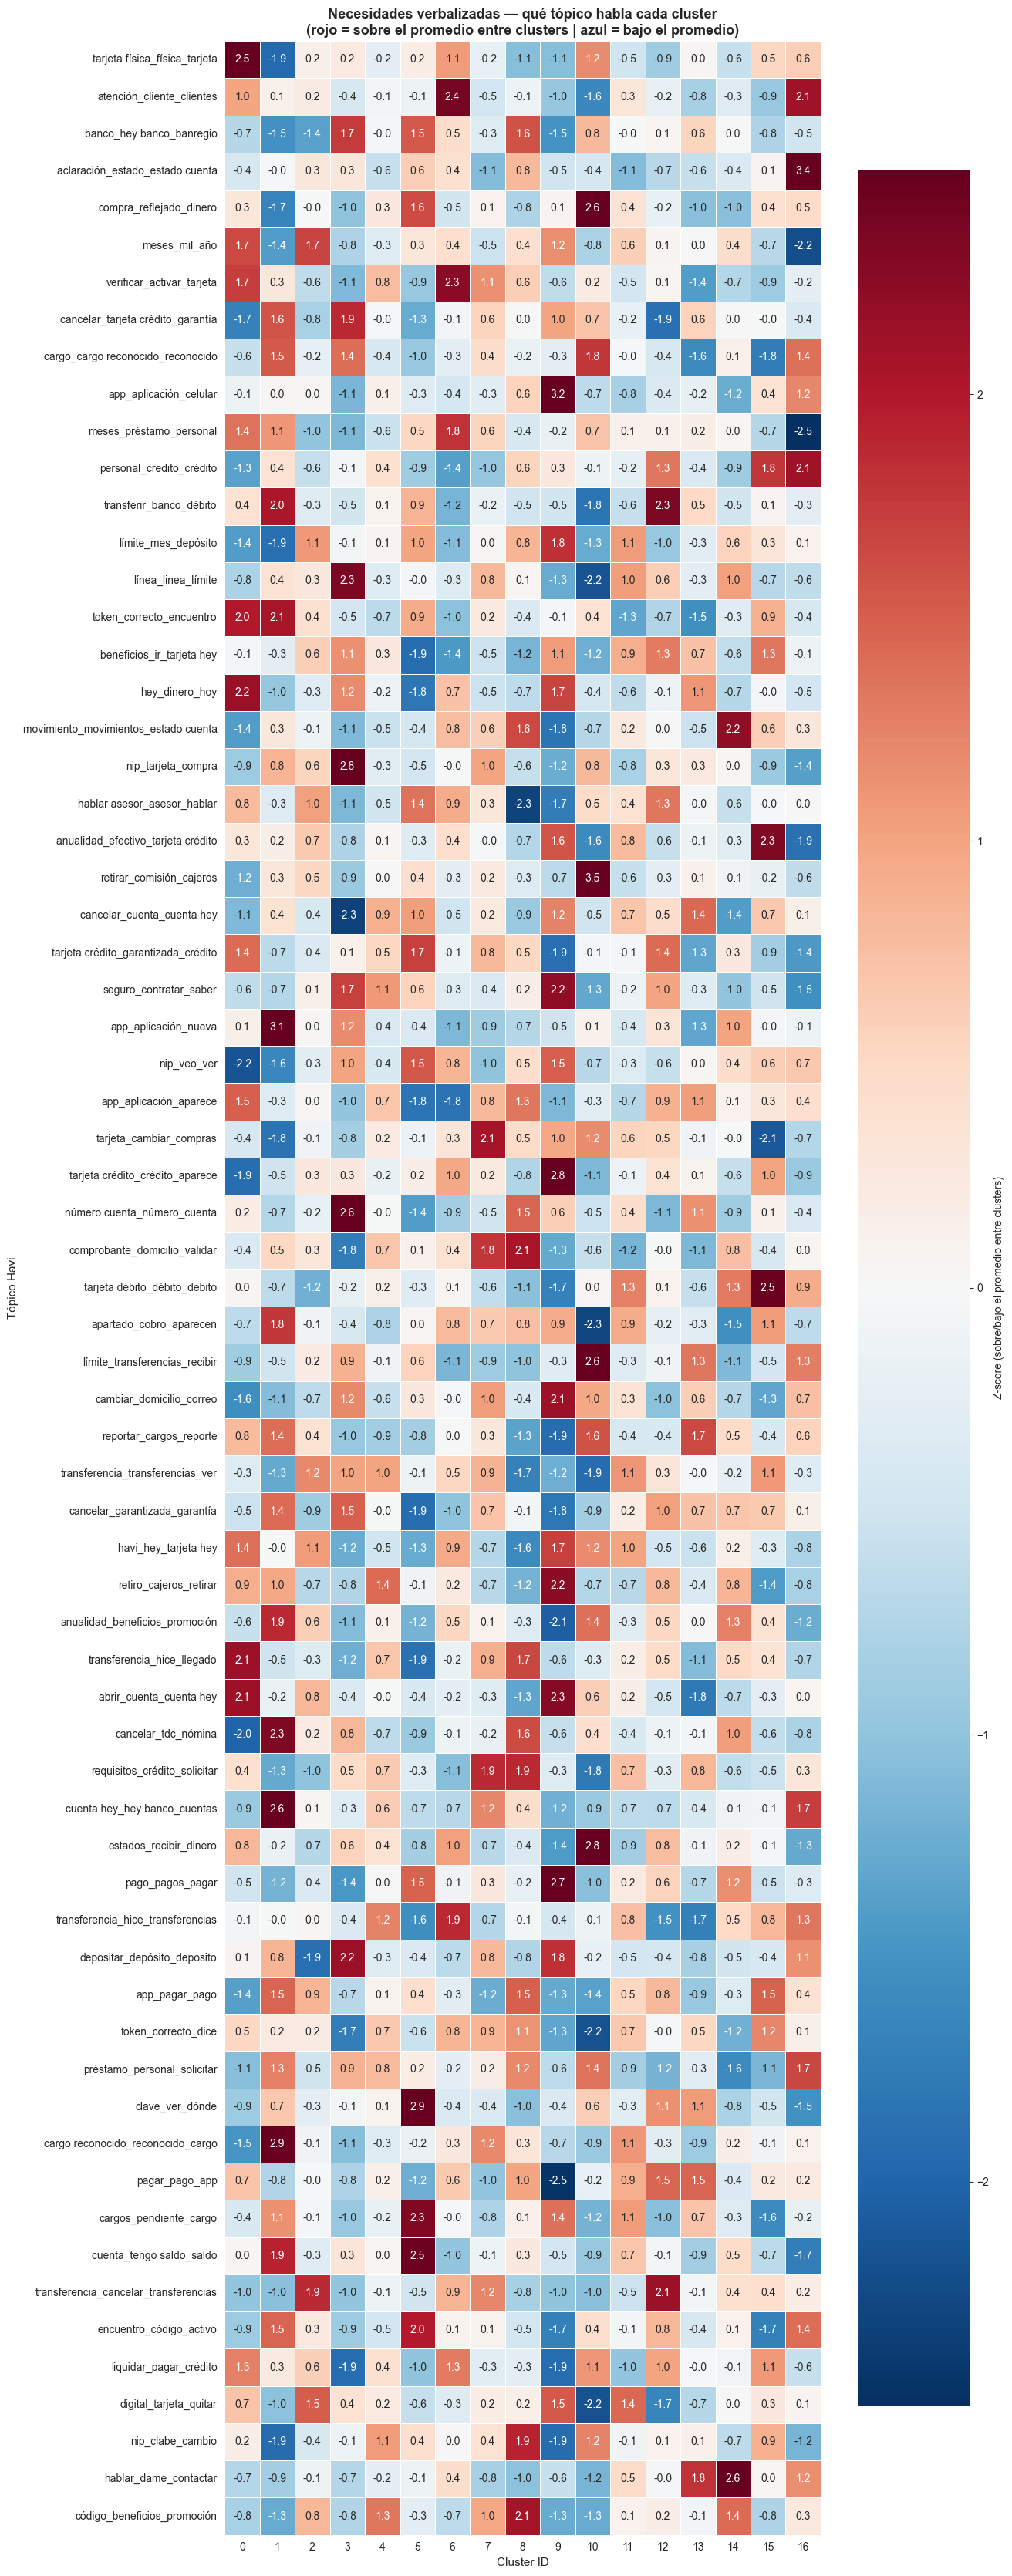

In [28]:
fig, ax = plt.subplots(figsize=(13, max(5, 0.5 * cluster_topic_matrix.shape[1])))

# Z-score para que las diferencias se vean dramáticas
sns.heatmap(
    z_matrix.T,  # transpuesto: tópicos en filas, clusters en columnas
    cmap='RdBu_r', center=0, annot=True, fmt='.1f',
    cbar_kws={'label': 'Z-score (sobre/bajo el promedio entre clusters)'},
    linewidths=0.5, ax=ax, vmin=-2.5, vmax=2.5
)
ax.set_title(
    'Necesidades verbalizadas — qué tópico habla cada cluster\n'
    '(rojo = sobre el promedio entre clusters | azul = bajo el promedio)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Tópico Havi', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/heatmap_cluster_topico.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Mapa de tópicos en BERTopic (interactivo)

Cada tópico es una burbuja; tamaño = volumen, distancia = similitud semántica. **Es interactivo en HTML — exportable para colgar en una sección del pitch.**

In [29]:
fig = topic_model.visualize_topics()
fig.write_html('../outputs/bertopic_mapa.html')
print('Mapa interactivo: ../outputs/bertopic_mapa.html')
fig

Mapa interactivo: ../outputs/bertopic_mapa.html


In [ ]:
# Bar chart de palabras clave por tópico (top 12 tópicos más grandes)
fig = topic_model.visualize_barchart(top_n_topics=12, n_words=8)
fig.write_html('../outputs/bertopic_palabras.html')
fig

In [ ]:
# Jerarquía de tópicos (cuáles agruparía si forzara menos)
fig = topic_model.visualize_hierarchy()
fig.write_html('../outputs/bertopic_jerarquia.html')
fig

### 8.3 Volumen de tópicos por cluster (apilado)

Otra forma de ver el cruce — útil para mostrar cómo se distribuye el "voice of customer" en cada segmento.

In [ ]:
# Stacked bar: cada cluster = una barra, segmentos = % por tópico
fig, ax = plt.subplots(figsize=(13, 6))

# Top tópicos para no saturar (los demás van en 'otros')
top_topics = cluster_topic_matrix.sum().sort_values(ascending=False).head(8).index.tolist()

data_plot = cluster_topic_matrix[top_topics].copy()
data_plot['otros'] = 1 - data_plot.sum(axis=1)
data_plot = data_plot.clip(lower=0)

data_plot.plot(kind='bar', stacked=True, ax=ax,
               colormap='tab20', edgecolor='white', linewidth=0.5)
ax.set_title('Distribución de necesidades verbalizadas por cluster',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('% de conversaciones')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/topicos_apilados_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Triggers híbridos: cuando tópico + comportamiento se alinean

Aquí está el oro del reto. Un trigger híbrido combina:
1. **Señal comportamental** (de transacciones/productos)
2. **Señal conversacional** (de Havi)

Cuando ambas señales apuntan al mismo "problema" o "oportunidad", la confianza se multiplica.

In [ ]:
# Ejemplo de triggers híbridos — adaptar a los tópicos REALES que aparezcan
# (estos son ejemplos asumiendo que esos tópicos salieron; ajustar al inspeccionar)

def evaluar_trigger_hibrido(master_df, condicion_comportamental, condicion_topico, nombre):
    """Evalúa cuántos usuarios cumplen las DOS condiciones (comportamiento + voz)."""
    sub = master_df[condicion_comportamental & condicion_topico]
    print(f'\n🎯 {nombre}')
    print(f'   Usuarios elegibles: {len(sub):,} ({100*len(sub)/len(master_df):.2f}% de la base)')
    print(f'   Distribución por cluster:')
    for cid, n in sub['cluster_id'].value_counts().head(5).items():
        print(f'     cluster {cid}: {n:,}')
    return sub

# Buscar columnas de tópico que tengan que ver con inversión (heurística por palabra clave)
topic_inversion_cols = [c for c in master_havi.columns 
                         if c.startswith('havi_topic_') and 
                         any(k in c.lower() for k in ['invers', 'ahorr', 'rendim'])]

topic_credito_cols = [c for c in master_havi.columns 
                       if c.startswith('havi_topic_') and 
                       any(k in c.lower() for k in ['credit', 'tarjet', 'limit'])]

topic_problema_cols = [c for c in master_havi.columns 
                        if c.startswith('havi_topic_') and 
                        any(k in c.lower() for k in ['problem', 'queja', 'error', 'bloque'])]

print(f'Columnas relacionadas con inversión: {topic_inversion_cols}')
print(f'Columnas relacionadas con crédito:   {topic_credito_cols}')
print(f'Columnas relacionadas con problema:  {topic_problema_cols}')

In [ ]:
# H1: cliente con saldo alto + sin inversión + habló de inversión = lead caliente
if topic_inversion_cols:
    cond_comp = (master_havi['flag_tiene_inversion'] == 0) & \
                (master_havi['tx_monto_total'] > master_havi['tx_monto_total'].quantile(0.6))
    cond_topic = master_havi[topic_inversion_cols].sum(axis=1) > 0
    h1 = evaluar_trigger_hibrido(
        master_havi, cond_comp, cond_topic,
        'H1: Lead caliente de inversión (alto saldo + sin inversión + habló de inversión)'
    )

# H2: cliente con stress crediticio + habló de problemas con tarjeta = soporte prioritario
if topic_problema_cols and 'cred_flag_alta_utilizacion' in master_havi.columns:
    cond_comp = master_havi['cred_flag_alta_utilizacion'] == 1
    cond_topic = master_havi[topic_problema_cols].sum(axis=1) > 0
    h2 = evaluar_trigger_hibrido(
        master_havi, cond_comp, cond_topic,
        'H2: Soporte prioritario (utilización alta + verbalizó problema)'
    )

# H3: cliente dormido + ninguna conversación reciente = riesgo de churn silencioso
cond_comp = (master_havi['cli_dormido_60d'] == 1)
cond_topic = master_havi['havi_n_convs'] == 1  # mínima interacción con Havi
h3 = evaluar_trigger_hibrido(
    master_havi, cond_comp, cond_topic,
    'H3: Churn silencioso (dormido 60d + casi no habla con Havi)'
)

# H4: alta fricción transaccional + canal voz = escalación humana
cond_comp = master_havi['tx_pct_no_procesada'] > 0.05
cond_topic = master_havi['havi_pct_voz'] > 0.5
h4 = evaluar_trigger_hibrido(
    master_havi, cond_comp, cond_topic,
    'H4: Escalación humana (fricción tx + prefiere voz)'
)

---
## 10. Export final

Los archivos que la persona de demo y la persona de pitch consumen:

In [ ]:
# 1. Master enriquecido con clusters + features Havi
master_havi.to_csv(f'{DATA_DIR}/master_clusters_havi.csv', index=False)

# 2. Tabla de conversaciones con tópico asignado
conversaciones.to_csv(f'{DATA_DIR}/conversaciones_topicos.csv', index=False)

# 3. Matriz cluster × tópico (para el pitch)
cluster_topic_matrix.to_csv(f'{DATA_DIR}/matriz_cluster_topico.csv')

# 4. Tabla de etiquetas de tópicos (para mantenimiento)
topic_info_export = topic_model.get_topic_info()
topic_info_export['etiqueta_humana'] = topic_info_export['Topic'].map(etiquetas_topicos)
topic_info_export.to_csv(f'{DATA_DIR}/topicos_info.csv', index=False)

# 5. Modelo BERTopic guardado (para asignar nuevos clientes en producción)
topic_model.save(f'{DATA_DIR}/bertopic_model', serialization='pickle')

print('Archivos generados:')
print(f'  ../data/master_clusters_havi.csv      ({master_havi.shape})')
print(f'  ../data/conversaciones_topicos.csv    ({conversaciones.shape})')
print(f'  ../data/matriz_cluster_topico.csv     ({cluster_topic_matrix.shape})')
print(f'  ../data/topicos_info.csv              ({topic_info_export.shape})')
print(f'  ../data/bertopic_model                (modelo persistido)')
print(f'  ../outputs/heatmap_cluster_topico.png')
print(f'  ../outputs/topicos_apilados_clusters.png')
print(f'  ../outputs/bertopic_*.html            (3 visualizaciones interactivas)')

---
## 11. Para defender en Q&A

**"¿Por qué BERTopic y no LDA?"**
- BERTopic usa embeddings semánticos contextuales (entiende sinónimos, contexto). LDA es bag-of-words puro y agrupa palabras que aparecen juntas, sin entender significado.
- BERTopic detecta el número de tópicos automáticamente vía HDBSCAN. LDA pide un `k` arbitrario.

**"¿Cómo validan que los tópicos son reales y no ruido?"**
- Coherencia visual del mapa interactivo (tópicos cercanos son semánticamente similares)
- Inspección humana de los documentos representativos
- Estabilidad: re-correr con `random_state` distinto debe producir tópicos similares

**"¿Qué pasa con clientes que no hablan con Havi?"**
- En este dataset el overlap es 100%, pero en producción se debería ofrecer triggers "silenciosos" basados solo en comportamiento (clusters), y reservar los triggers híbridos para los que sí verbalizan.

**"¿Cómo se actualiza en producción?"**
- El modelo BERTopic guardado puede usar `topic_model.transform(nueva_conv, embeddings=nuevo_emb)` para asignar tópico a conversaciones nuevas sin re-entrenar.
- Re-entrenar el modelo cada 30-60 días para capturar nuevos temas (ej: nuevo producto que se lanza).

**"¿Cómo cuantifican el impacto?"**
- Cada trigger tiene una población elegible cuantificada (ver sección 9).
- Con conversion rate típicas de la industria (3-8% para cross-sell, 15-25% para retención proactiva), se estima el impacto de revenue.
- Comparar contra el escenario actual de ofertas masivas no segmentadas, donde la conversion suele ser <1%.